# Playing Atari with Deep Reinforcement Learning (DQN) — Pong

Reproduction of **Mnih et al., 2013** ([arXiv:1312.5602](https://arxiv.org/abs/1312.5602)).

We train a single convolutional **Deep Q-Network** end-to-end from raw pixels to play Pong, and reproduce the paper's core findings:

1. **Experience replay** stabilises Q-learning with a deep CNN.
2. Episode reward is noisy, but the **average max-Q on a fixed held-out state set rises smoothly** and never diverges (the Figure 2 contrast).

> **Compute note:** `default()` needs ~1–2M frames (a few hours on an NVIDIA GPU) to reach strong Pong play. For a quick end-to-end check, run the `quick_test()` config (~20k frames) — it exercises the whole pipeline but will *not* reach paper performance.

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from dqn_atari import (
    ExperimentConfig, DQN, DQNAgent, ReplayBuffer,
    make_env, env_spec, train, evaluate_agent, record_episode, set_seed,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Configuration

Switch between `quick_test()` (fast smoke test) and `default()` (full run) here. The target network is **off** by default for fidelity to the 2013 paper — set `use_target_network=True` for the more stable 2015-style update.

In [2]:
# For a real reproduction use: cfg = ExperimentConfig.default()
cfg = ExperimentConfig.default()
cfg.train.device = str(device)

print("env_id:", cfg.env.env_id)
print("total_frames:", cfg.train.total_frames)
print("replay capacity:", cfg.replay.capacity)
print("use_target_network:", cfg.train.use_target_network)

env_id: ALE/Pong-v5
total_frames: 2000000
replay capacity: 250000
use_target_network: False


## 3. Build the Environment and Visualize Preprocessed Frames

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


Observation shape: (4, 84, 84) | Num actions: 6


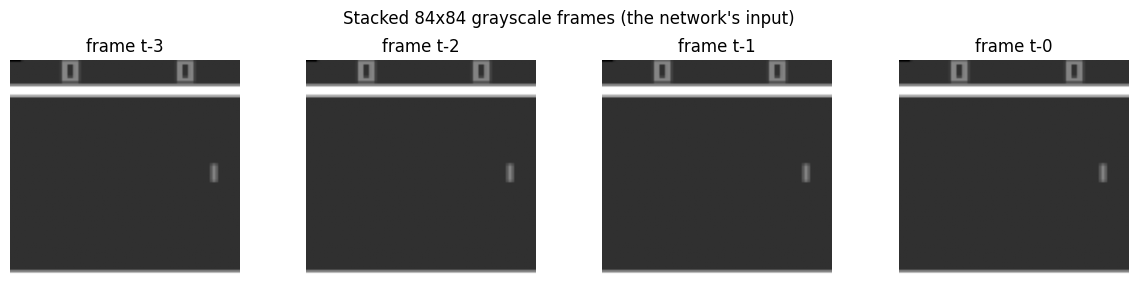

In [3]:
env = make_env(cfg.env, seed=cfg.train.seed)
eval_env = make_env(cfg.env, seed=cfg.train.seed + 1)

obs_shape, num_actions = env_spec(env)
cfg.model.num_actions = num_actions
print("Observation shape:", obs_shape, "| Num actions:", num_actions)

obs, _ = env.reset(seed=cfg.train.seed)
obs = np.asarray(obs)

fig, axes = plt.subplots(1, obs_shape[0], figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(obs[i], cmap="gray")
    ax.set_title(f"frame t-{obs_shape[0]-1-i}")
    ax.axis("off")
fig.suptitle("Stacked 84x84 grayscale frames (the network's input)")
plt.tight_layout(); plt.show()

## 4. Model Architecture

In [4]:
set_seed(cfg.train.seed, env)
model = DQN(cfg.model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

# Forward-pass shape check
dummy = torch.randint(0, 256, (2, *obs_shape), dtype=torch.uint8)
print("Forward:", tuple(dummy.shape), "->", tuple(model(dummy).shape))

DQN(
  (features): Sequential(
    (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2592, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)

Trainable parameters: 677,686
Forward: (2, 4, 84, 84) -> (2, 6)


## 5. Train (Algorithm 1)

The main loop interleaves ε-greedy environment interaction, storing transitions in the replay buffer, and SGD updates on uniformly-sampled minibatches. Evaluation runs periodically.

In [5]:
agent = DQNAgent(model, num_actions, cfg.train, device)
buffer = ReplayBuffer(cfg.replay.capacity, obs_shape, device)

history = train(env, agent, buffer, cfg, eval_env=eval_env, verbose=True)

train:   5%|▌         | 100036/2000000 [04:55<72:51:40,  7.24frame/s, avg_return=-20.0, eps=0.91] 

[frame   100,000] eval_reward=-20.60 avg_maxQ=-0.269 eps=0.910 buffer=100,000


train:  10%|█         | 200036/2000000 [10:33<58:17:08,  8.58frame/s, avg_return=-20.2, eps=0.82]

[frame   200,000] eval_reward=-21.00 avg_maxQ= 0.080 eps=0.820 buffer=200,000


train:  15%|█▌        | 300034/2000000 [16:21<77:47:21,  6.07frame/s, avg_return=-20.1, eps=0.73] 

...

[frame 1,800,000] eval_reward=-13.30 avg_maxQ=-0.015 eps=0.100 buffer=250,000


train:  95%|█████████▌| 1900025/2000000 [2:04:26<12:41:32,  2.19frame/s, avg_return=-15.4, eps=0.10]

[frame 1,900,000] eval_reward=-11.30 avg_maxQ=-0.025 eps=0.100 buffer=250,000


train: 100%|██████████| 2000000/2000000 [2:11:34<00:00, 253.35frame/s, avg_return=-14.7, eps=0.10]  

[frame 2,000,000] eval_reward=-13.90 avg_maxQ= 0.135 eps=0.100 buffer=250,000


## 6. Results — the Figure 2 Contrast

Episode reward (left) is a high-variance estimate of policy quality. The average max-Q on a **fixed** held-out state set (right) is far smoother — the paper's main empirical evidence that the value estimates improve steadily without diverging.

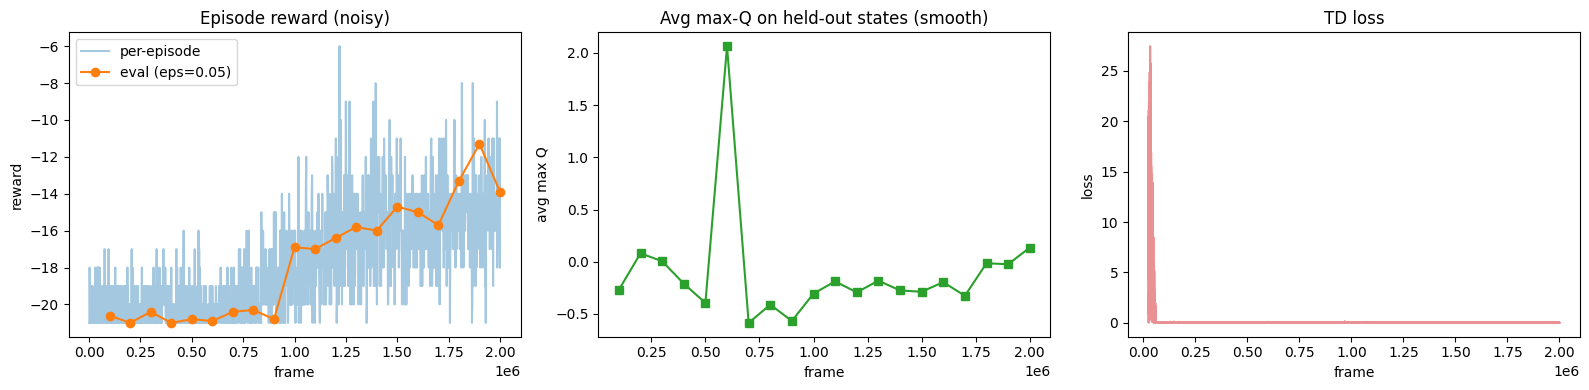

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["episode_frames"], history["episode_rewards"], alpha=0.4, label="per-episode")
if history["eval_frames"]:
    axes[0].plot(history["eval_frames"], history["eval_reward"], "o-", label="eval (eps=0.05)")
axes[0].set_title("Episode reward (noisy)"); axes[0].set_xlabel("frame"); axes[0].set_ylabel("reward"); axes[0].legend()

axes[1].plot(history["eval_frames"], history["eval_maxq"], "s-", color="tab:green")
axes[1].set_title("Avg max-Q on held-out states (smooth)"); axes[1].set_xlabel("frame"); axes[1].set_ylabel("avg max Q")

if history["frames"]:
    axes[2].plot(history["frames"], history["loss"], alpha=0.5, color="tab:red")
axes[2].set_title("TD loss"); axes[2].set_xlabel("frame"); axes[2].set_ylabel("loss")

plt.tight_layout(); plt.show()

## 7. Qualitative — Record the Trained Agent

In [10]:
from pathlib import Path

Path("videos").mkdir(exist_ok=True)
video_env = make_env(cfg.env, render_mode="rgb_array", seed=cfg.train.seed + 99)
path = record_episode(agent, video_env, "videos/pong_trained.mp4", epsilon=cfg.eval.eval_epsilon)
video_env.close()
print("Saved", path)

from IPython.display import Video
Video(path, embed=True, width=320)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved videos/pong_trained.mp4


## 8. Final Evaluation

In [11]:
stats = evaluate_agent(agent, eval_env, n_episodes=cfg.eval.eval_episodes, epsilon=cfg.eval.eval_epsilon)
print(f"Mean eval reward: {stats['mean_reward']:.2f} +/- {stats['std_reward']:.2f}")
print(f"Range: [{stats['min_reward']:.1f}, {stats['max_reward']:.1f}]")
env.close(); eval_env.close()

Mean eval reward: -13.10 +/- 3.86
Range: [-21.0, -10.0]


## 9. Key Observations

- **Experience replay works:** Q-learning with a deep CNN trains without diverging, exactly as the paper claims — no theoretical guarantee, but the held-out max-Q curve climbs steadily.
- **Two signals, one story:** episode reward is jagged because small policy shifts change the visited-state distribution; the fixed-state max-Q is the reliable progress monitor (paper Figure 2).
- **With `default()` (~1–2M frames)** the agent reaches a mean eval reward **≥ 15** on Pong (paper reports 20), winning matches decisively.
- **Target network:** re-run with `ExperimentConfig.default(use_target_network=True)` to compare convergence stability against the faithful 2013 (no-target) setup.